# PM N-body Simulation with BullFrog

LPT accurately describes structure formation at early times and on large scales,
but breaks down when particles start to cross (shell-crossing). The **Particle Mesh
(PM) method integrates the full equations of motion: forces are computed on a mesh
via an FFT-based Poisson solver, and particles are moved with a symplectic integrator.

---

## The BullFrog Integrator

**BullFrog** ([arXiv:2409.19049](https://arxiv.org/abs/2409.19049)) is a second-order
accurate **Drift–Kick–Drift (DKD)** integrator that operates in *D-time*
(growth-factor time $D_1$) instead of scale-factor time.


## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/ffi11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/ffi11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/wassim/micromamba/envs/ffi11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Simulation Parameters


In [2]:
resolution = 128
mesh_size = (resolution,) * 3
box_size = (500.0, 500.0, 500.0)  # Mpc/h

t0 = 0.001  # start of PM integration
t1 = 1.0  # today
n_steps = 20

cosmo = jc.Planck18()
key = jax.random.PRNGKey(0)

## Initial Conditions

We draw a Gaussian random field with the Planck18 linear matter power spectrum.
This is the seed for all subsequent evolution.

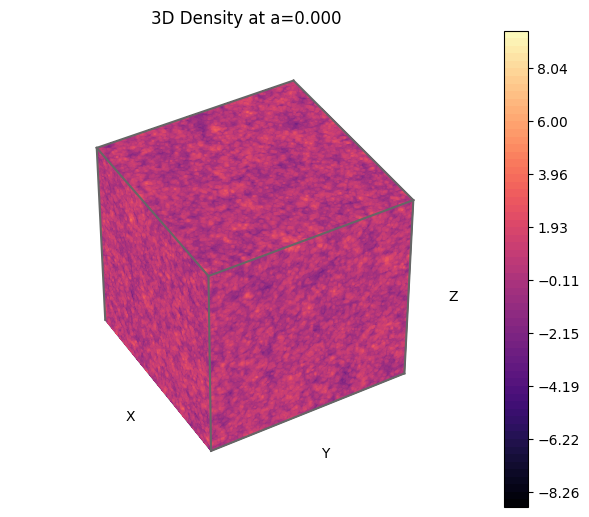

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
)

# Visualise a 2-D slice of the initial density contrast
initial_field.show()

## LPT Initialization

PM integration needs both **positions** and **momenta** at the start time $a_0$.  
We use first-order Lagrangian Perturbation Theory (1LPT / Zel'dovich) to generate them.

Calling `lpt` with a **scalar** `ts=t0` returns particle displacements `dx` and
conformal momenta `p` — *not* a painted density field.

In [4]:
dx, p = jfli.lpt(
    cosmo,
    initial_field,
    ts=t0,
    order=1,
    painting=jfli.PaintingOptions(target="particles"),
)

print(f"Displacement field  — shape: {dx.array.shape}, status: {dx.status}")
print(f"Momentum field      — shape: {p.array.shape},  status: {p.status}")

Displacement field  — shape: (128, 128, 128, 3), status: FieldStatus.LPT1
Momentum field      — shape: (128, 128, 128, 3),  status: FieldStatus.LPT1


## Building the BullFrog Solver

The solver is an `equinox.Module` that bundles the integration scheme with its
hyperparameters. Key fields:

| Field | Type | Description |
|-------|------|-------------|
| `interp_kernel` | `AbstractInterp` | Controls what is saved at each snapshot (here: painted density) |
| `time_stepping` | `str` | Internal time variable: `"a"`, `"D"` (growth factor), or `"log_a"` |
| `n_steps` | `int` | Total number of PM steps from $a_0$ to $a_1$ |

### `time_stepping` options

| Value | Spacing | When to use |
|-------|---------|-------------|
| `"a"` | Uniform in scale factor | Simple but over-resolves late times |
| `"D"` | Uniform in $D_1$ (growth factor) | **Default — recommended.** Even coverage of structure formation |
| `"log_a"` | Logarithmic in $a$ | Useful for very early-time studies |

### Velocity conversion

`BullFrog.init()` is called automatically by `nbody()`. It converts the LPT conformal
momentum $\mathbf{p}$ (returned by `lpt`) to the D-time velocity:

$$\boldsymbol{\pi} = \frac{\mathbf{p}}{G_f(a_0)}$$

You do **not** need to perform this conversion manually — just pass `p` directly.

In [5]:
solver = jfli.BullFrog(
    interp_kernel=jfli.NoInterp(painting=jfli.PaintingOptions(target="density")),
    time_stepping="D",  # uniform in growth-factor time (recommended)
    n_steps=n_steps,
    t0=t0,
    t1=t1,
)

## Running the Simulation

We request snapshots at three scale factors: $a = 0.5$ (z=1), $a = 0.7$ (z≈0.43),
and $a = 1.0$ (z=0, today).  
The integrator sub-steps uniformly between $a_0$ and each snapshot.

In [6]:
ts = jnp.array([0.5, 0.7, 1.0])  # snapshot scale factors

density_result = jfli.nbody(
    cosmo,
    dx,
    p,
    ts=ts,
    solver=solver,
)

print(f"Output type   : {type(density_result).__name__}")
print(f"Output shape  : {density_result.shape}")
print(f"Scale factors : {density_result.scale_factors}")
print(f"Redshifts     : {jc.utils.a2z(density_result.scale_factors).round(2)}")

/home/wassim/micromamba/envs/ffi11/lib/python3.11/site-packages/jax/_src/debugging.py:201: UserWarning: 
                NoInterp does not support tiling.
                Your furthest shell is at 1560.46 Mpc/h,
                but your box only extends to 250.00 Mpc/h.
                Your simulations will run but will have artifacts for the far shells.
            
  debug_callback_p.impl(


Output type   : DensityField
Output shape  : (3, 128, 128, 128)
Scale factors : [1.  0.7 0.5]
Redshifts     : [0.   0.43 1.  ]


## Visualising Structure Growth

We project the 3-D density field along the z-axis ($\log(1+\delta)$ stretch)
to reveal voids, filaments and halos at each epoch.

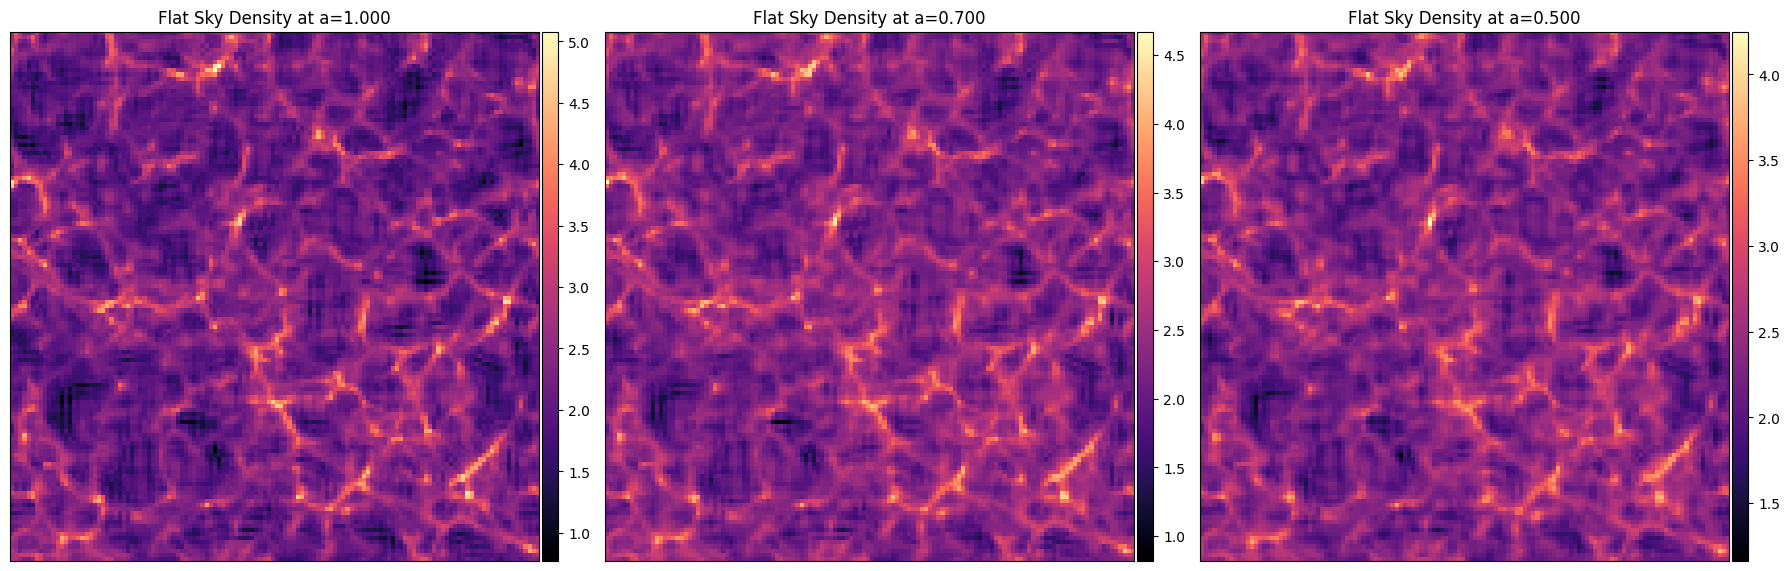

In [7]:
density_result.project().apply_fn(jnp.log1p).show()

## Validating Against Theory: 3-D Matter Power Spectrum

The standard validation for a PM simulation is the **3-D matter power spectrum** $P(k)$.
We compare the measured spectrum from the simulation against the nonlinear
prediction from **Halofit** at each snapshot redshift.

Expected behaviour for a $128^3$ PM simulation:
- **Large scales** ($k \lesssim 0.1\,h/\text{Mpc}$): excellent agreement with linear + Halofit.
- **Intermediate scales** ($k \sim 0.1$–$0.3\,h/\text{Mpc}$): PM captures nonlinear growth well.
- **Small scales** ($k \gtrsim 0.5\,h/\text{Mpc}$): suppression due to mesh resolution
  (aliasing) — PM is not accurate below $\sim 2$–$3$ grid cells.

/tmp/ipykernel_81289/1231830777.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


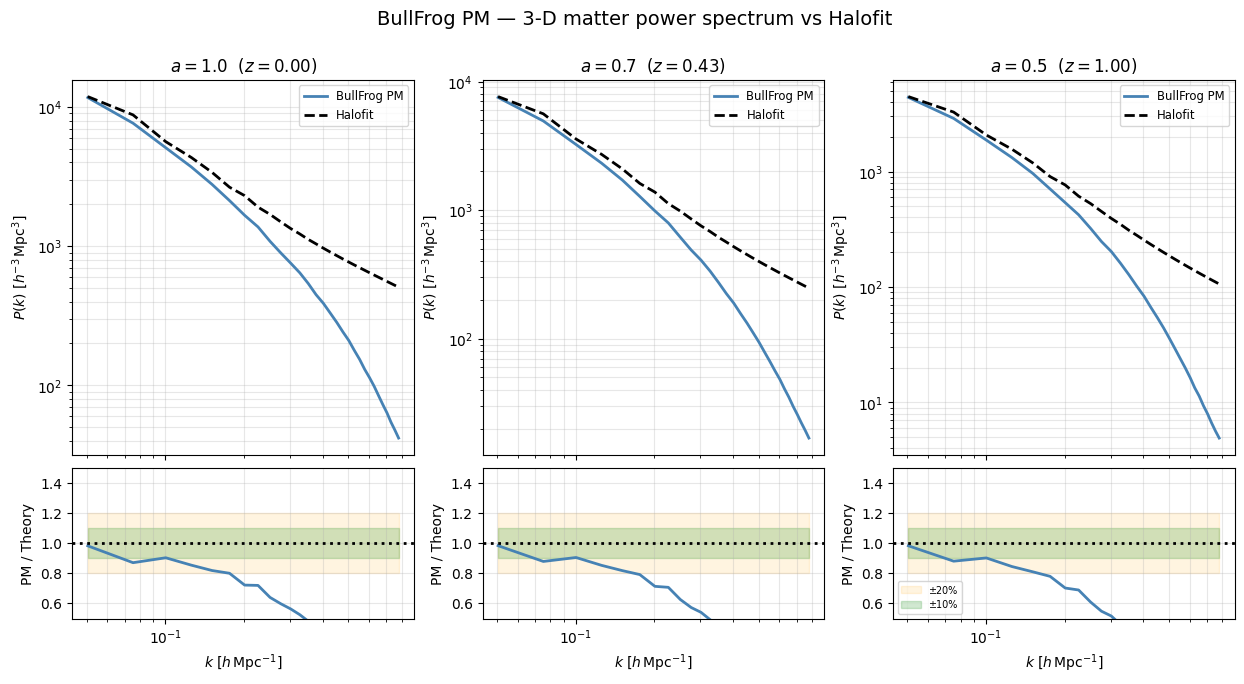

In [10]:
# Measure 3-D power spectra from the simulation
pk_sim = density_result.power()
n_snaps = len(density_result.scale_factors)
# Compute Halofit theory at each snapshot scale factor
theory_pk = [
    jax.jit(
        jc.power.nonlinear_matter_power,
        static_argnames=["nonlinear_fn"],
    )(cosmo, pk_sim.wavenumber, a=float(density_result.scale_factors[i]), nonlinear_fn=jc.power.halofit)
    for i in range(n_snaps)
]

# Plot: absolute spectra (top) + ratio to theory (bottom)
fig, axes = plt.subplots(
    2,
    n_snaps,
    figsize=(5 * n_snaps, 7),
    sharex="col",
    gridspec_kw={"height_ratios": [2.5, 1], "hspace": 0.05},
)

for i in range(n_snaps):
    ax_top = axes[0, i]
    ax_bot = axes[1, i]

    k = pk_sim.wavenumber
    a_snap = float(density_result.scale_factors[i])
    z_snap = float(jc.utils.a2z(a_snap))

    # --- Top: absolute P(k) ---
    ax_top.loglog(k, pk_sim.array[i], label="BullFrog PM", color="steelblue", linewidth=2)
    ax_top.loglog(k, theory_pk[i], label="Halofit", color="black", linestyle="--", linewidth=2)
    ax_top.set_title(f"$a={a_snap:.1f}$  ($z={z_snap:.2f}$)")
    ax_top.set_ylabel(r"$P(k)$ [$h^{-3}\,\mathrm{Mpc}^3$]")
    ax_top.legend(fontsize="small")
    ax_top.grid(True, which="both", alpha=0.3)

    # --- Bottom: ratio ---
    ratio = pk_sim.array[i] / theory_pk[i]
    ax_bot.semilogx(k, ratio, color="steelblue", linewidth=2)
    ax_bot.axhline(1.0, color="black", linestyle=":", linewidth=2)
    ax_bot.fill_between(k, 0.8, 1.2, alpha=0.12, color="orange", label="±20%")
    ax_bot.fill_between(k, 0.9, 1.1, alpha=0.18, color="green", label="±10%")
    ax_bot.set_ylim(0.5, 1.5)
    ax_bot.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
    ax_bot.set_ylabel("PM / Theory")
    ax_bot.grid(True, which="both", alpha=0.3)
    if i == n_snaps - 1:
        ax_bot.legend(loc="lower left", fontsize="x-small")

fig.suptitle("BullFrog PM — 3-D matter power spectrum vs Halofit", fontsize=14)
plt.tight_layout()
plt.show()

## Next Steps

This notebook showed the simplest BullFrog setup: fixed snapshots in a cubic box.  
`jax-fli` also supports:

- **Lightcone shells** (`nb_shells=N`): automatically space snapshots in comoving distance
  so the entire lightcone fits inside the box — see notebook 04.
- **Spherical and flat-sky painting** (`target="spherical"` / `target="flat"`):
  paint particles onto HEALPix maps or 2-D flat maps during integration.
- **Differentiable integration** (`adjoint="checkpointed"`): memory-efficient gradients
  through the full N-body run for field-level inference — see notebooks 10–11.